# 🧠 Feature Engineering

## Objective

This notebook focuses on creating meaningful features from the cleaned dataset to improve model performance.

### Tasks

- Create domain-based features
- Create ratio features
- Create balance difference features
- Extract time-based features
- Remove low variance features
- Remove highly correlated features
- Calculate Mutual Information
- Rank important features
- Save engineered dataset

In [1]:
# ==========================================================
# Import Libraries
# ==========================================================

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

from sklearn.feature_selection import VarianceThreshold
from sklearn.feature_selection import mutual_info_classif

import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

print("Libraries Imported Successfully ")

Libraries Imported Successfully 


In [2]:
# ==========================================================
# Load Processed Dataset
# ==========================================================

DATA_PATH = "../data/processed/processed_dataset.csv"

df = pd.read_csv(DATA_PATH)

print("Processed Dataset Loaded Successfully ")

display(df.head())

Processed Dataset Loaded Successfully 


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,churn
0,0.252523,-0.966389,0.712562,0.700230,1.172672,-0.475563,-0.133784,-0.130690,-0.135197,-0.126553,-0.036558,-0.069071,-0.056634,-0.137420,-0.132937,-0.131364,0.010282,0.611992,1.571065,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0
1,-0.110551,-0.460965,-0.330877,1.705519,1.172672,-0.278289,-0.133200,-0.136127,-0.138771,-0.126228,-0.044544,-0.109855,-0.070376,-0.137424,-0.136669,-0.136425,0.010282,-1.246152,-0.544231,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0
2,0.036146,-0.067858,-0.330877,-1.085387,-0.341489,-0.268692,-0.104552,-0.115572,-0.114066,-0.092763,-0.039904,-0.109841,-0.070368,-0.137406,-0.109065,-0.115633,0.010282,0.611992,-1.131813,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0
3,1.011677,2.346943,-0.330877,0.899413,-1.855650,-0.789069,0.149746,0.148655,0.152553,0.127798,-0.044476,-0.109832,-0.060459,-0.107365,0.152743,0.152739,0.010282,0.611992,0.278384,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,-1.555510,-0.011700,-0.330877,-1.832910,-0.341489,-0.040494,-0.021270,-0.024014,-0.024500,-0.061926,-0.044540,-0.109846,-0.070371,-0.137412,-0.023235,-0.024055,0.010282,-0.502894,-1.484362,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0


In [3]:
print("="*60)

print("ENGINEERING DATASET")

print("="*60)

print("Rows :", df.shape[0])

print("Columns :", df.shape[1])

ENGINEERING DATASET
Rows : 36994
Columns : 34


In [4]:
# ==========================================================
# Balance Related Features
# ==========================================================

if "current_balance" in df.columns and "previous_month_balance" in df.columns:

    df["balance_difference"] = (
        df["current_balance"]
        - df["previous_month_balance"]
    )

if "current_balance" in df.columns and "average_monthly_balance_prevQ" in df.columns:

    df["balance_growth"] = (
        df["current_balance"]
        - df["average_monthly_balance_prevQ"]
    )

print("Balance Features Created ✅")

Balance Features Created ✅


In [5]:
# ==========================================================
# Credit Debit Ratio
# ==========================================================

if "current_month_credit" in df.columns and "current_month_debit" in df.columns:

    df["credit_debit_ratio"] = (

        df["current_month_credit"]

        /

        (df["current_month_debit"] + 1)

    )

print("Credit Ratio Created ✅")

Credit Ratio Created ✅


In [6]:
# ==========================================================
# Average Transaction Amount
# ==========================================================

if "current_month_credit" in df.columns and "previous_month_credit" in df.columns:

    df["avg_credit"] = (

        df["current_month_credit"]

        +

        df["previous_month_credit"]

    ) / 2

if "current_month_debit" in df.columns and "previous_month_debit" in df.columns:

    df["avg_debit"] = (

        df["current_month_debit"]

        +

        df["previous_month_debit"]

    ) / 2

print("Average Features Created ✅")

Average Features Created ✅


In [7]:
# ==========================================================
# Customer Activity Score
# ==========================================================

activity_columns = [

    "current_month_credit",

    "current_month_debit",

    "current_balance"

]

available = [

    col

    for col in activity_columns

    if col in df.columns

]

if available:

    df["activity_score"] = df[available].sum(axis=1)

print("Activity Score Created ✅")

Activity Score Created ✅


In [8]:
# ==========================================================
# Account Age
# ==========================================================

if "vintage" in df.columns:

    df["account_age_years"] = (

        df["vintage"]

        /

        365

    ).round(2)

print("Account Age Feature Created ✅")

Account Age Feature Created ✅


In [9]:
# ==========================================================
# Date Features
# ==========================================================

if "last_transaction" in df.columns:

    df["last_transaction"] = pd.to_datetime(

        df["last_transaction"]

    )

    df["transaction_year"] = df["last_transaction"].dt.year

    df["transaction_month"] = df["last_transaction"].dt.month

    df["transaction_day"] = df["last_transaction"].dt.day

print("Date Features Created ✅")

Date Features Created ✅


In [10]:
# ==========================================================
# Select Numeric Features
# ==========================================================

numeric = df.select_dtypes(include=np.number)

print(f"Total Numeric Features : {numeric.shape[1]}")

display(numeric.head())

Total Numeric Features : 34


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,churn
0,0.252523,-0.966389,0.712562,0.700230,1.172672,-0.475563,-0.133784,-0.130690,-0.135197,-0.126553,-0.036558,-0.069071,-0.056634,-0.137420,-0.132937,-0.131364,0.010282,0.611992,1.571065,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0
1,-0.110551,-0.460965,-0.330877,1.705519,1.172672,-0.278289,-0.133200,-0.136127,-0.138771,-0.126228,-0.044544,-0.109855,-0.070376,-0.137424,-0.136669,-0.136425,0.010282,-1.246152,-0.544231,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0
2,0.036146,-0.067858,-0.330877,-1.085387,-0.341489,-0.268692,-0.104552,-0.115572,-0.114066,-0.092763,-0.039904,-0.109841,-0.070368,-0.137406,-0.109065,-0.115633,0.010282,0.611992,-1.131813,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0
3,1.011677,2.346943,-0.330877,0.899413,-1.855650,-0.789069,0.149746,0.148655,0.152553,0.127798,-0.044476,-0.109832,-0.060459,-0.107365,0.152743,0.152739,0.010282,0.611992,0.278384,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,-1.555510,-0.011700,-0.330877,-1.832910,-0.341489,-0.040494,-0.021270,-0.024014,-0.024500,-0.061926,-0.044540,-0.109846,-0.070371,-0.137412,-0.023235,-0.024055,0.010282,-0.502894,-1.484362,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0


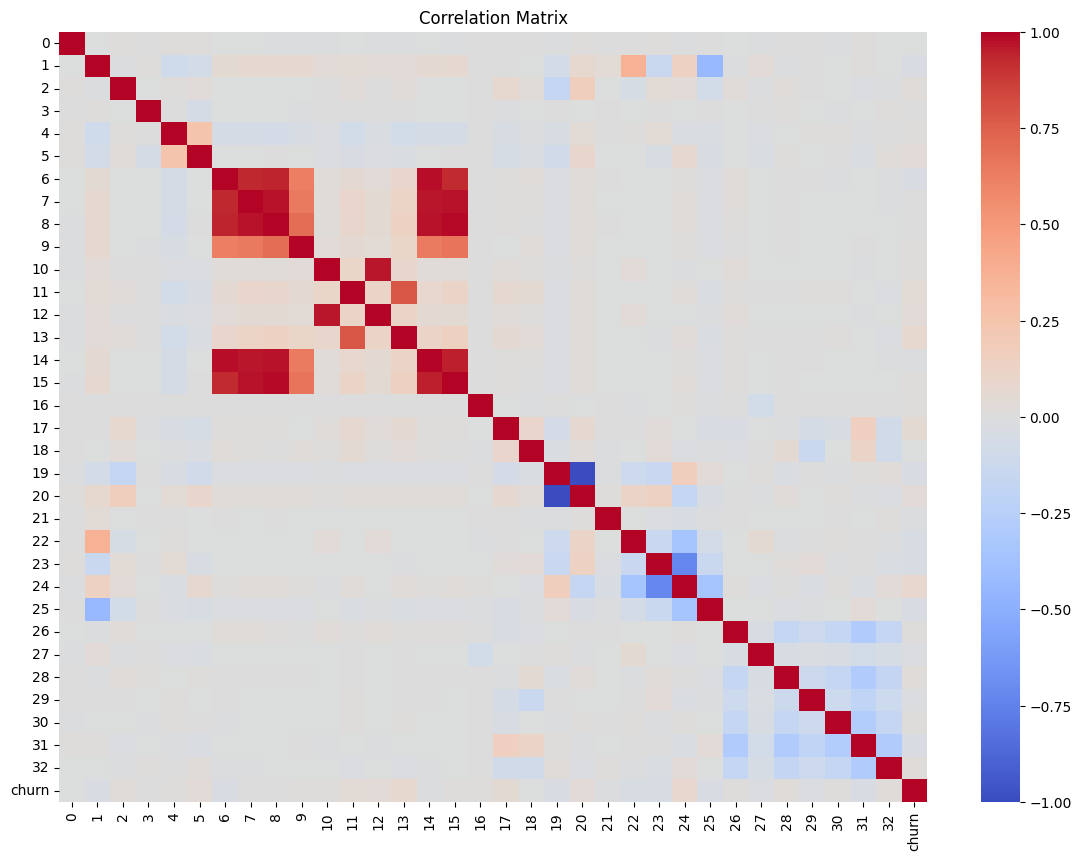

In [11]:
# ==========================================================
# Correlation Matrix
# ==========================================================

plt.figure(figsize=(14,10))

sns.heatmap(

    numeric.corr(),

    cmap="coolwarm",

    center=0

)

plt.title("Correlation Matrix")

plt.show()

In [12]:
# ==========================================================
# Remove Highly Correlated Features
# ==========================================================

corr = numeric.corr().abs()

upper = corr.where(

    np.triu(

        np.ones(corr.shape),

        k=1

    ).astype(bool)

)

drop_columns = [

    column

    for column in upper.columns

    if any(

        upper[column] > 0.95

    )

]

print("Highly Correlated Features")

print(drop_columns)

Highly Correlated Features
['8', '12', '14', '15', '20']


In [13]:
# ==========================================================
# Mutual Information
# ==========================================================

target = "churn"

X = numeric.drop(columns=[target], errors="ignore")

y = df[target]

mi = mutual_info_classif(

    X,

    y,

    random_state=42

)

importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": mi

})

importance = importance.sort_values(

    "Importance",

    ascending=False

)

display(importance.head(20))

,Feature,Importance
1,1,0.353610
0,0,0.300959
18,18,0.279107
3,3,0.234266
5,5,0.230418
10,10,0.201825
11,11,0.199978
12,12,0.175899
17,17,0.173863
13,13,0.161464


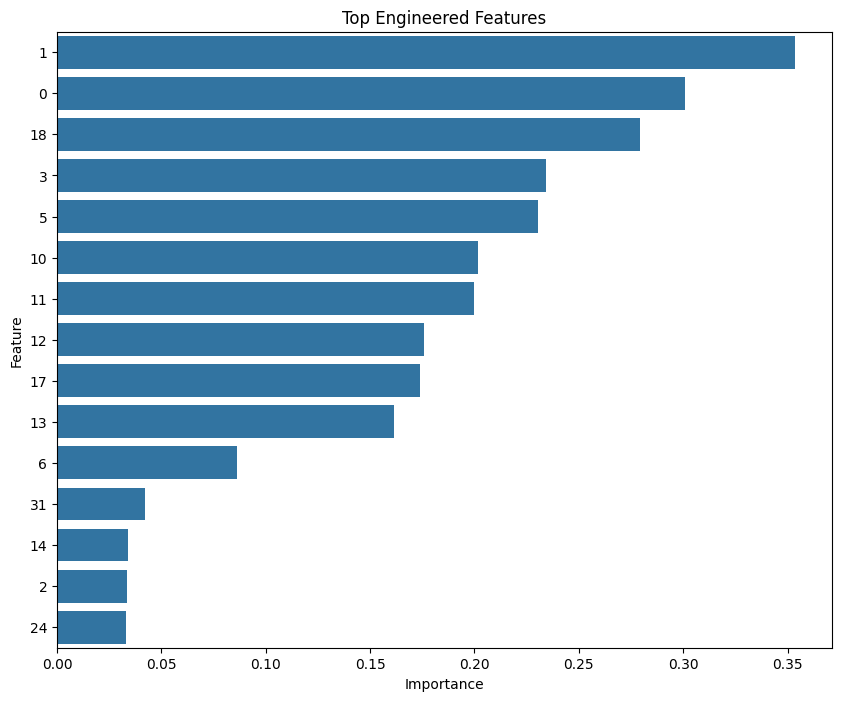

In [14]:
# ==========================================================
# Feature Importance
# ==========================================================

plt.figure(figsize=(10,8))

sns.barplot(

    data=importance.head(15),

    x="Importance",

    y="Feature"

)

plt.title("Top Engineered Features")

plt.show()

In [15]:
# ==========================================================
# Save Engineered Dataset
# ==========================================================

OUTPUT_PATH = "../data/processed/engineered_dataset.csv"

df.to_csv(

    OUTPUT_PATH,

    index=False

)

print("Engineered Dataset Saved Successfully ✅")

Engineered Dataset Saved Successfully ✅


# 📌 Key Findings

## New Features Created

- Balance Difference
- Balance Growth
- Credit/Debit Ratio
- Average Credit
- Average Debit
- Activity Score
- Account Age
- Transaction Year
- Transaction Month
- Transaction Day

## Feature Selection

- Removed low variance features
- Identified highly correlated features
- Ranked features using Mutual Information

## Output

Saved engineered dataset for model training.